Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score,  f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

Exploratory Data Analysis

In [37]:
df=pd.read_csv('/Users/mukilvannan/Documents/my_projects/diabetes_risk_prediction/diabetes_prediction_dataset.csv')

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [39]:
print("shape of the dataset:", df.shape)

shape of the dataset: (100000, 9)


In [40]:
df.describe()


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [41]:
df.isnull().sum()


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [42]:
df.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

In [43]:
print("No of duplicate :", df.duplicated().sum())

No of duplicate : 3854


Data Cleaning

In [44]:
df=df.drop_duplicates()
cat_cols =['gender','smoking_history']
for col in cat_cols:
    df[col]=df[col].astype('category') #converting to category type 

In [45]:
print('Duplicates:',df.duplicated().sum())

Duplicates: 0


In [46]:
df.shape

(96146, 9)

Data Visualization

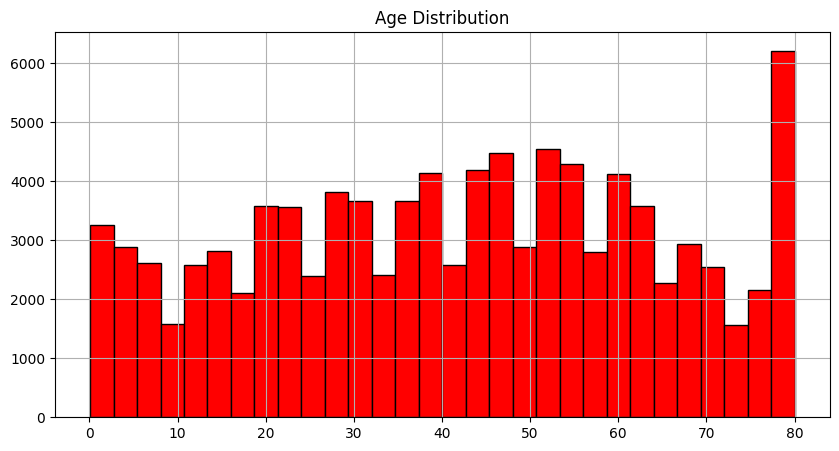

In [47]:
plt.figure(figsize=(10,5))
df['age'].hist(bins=30, color='red', edgecolor='black')
plt.title('Age Distribution')
plt.show()

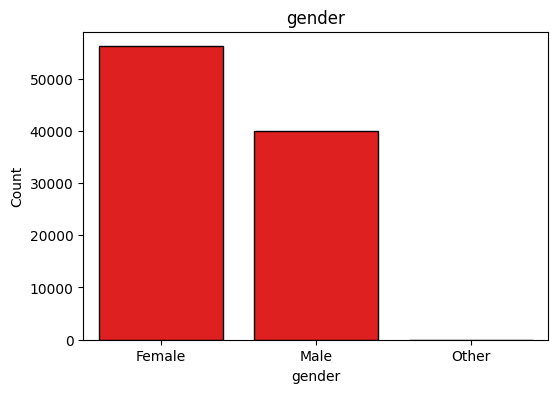

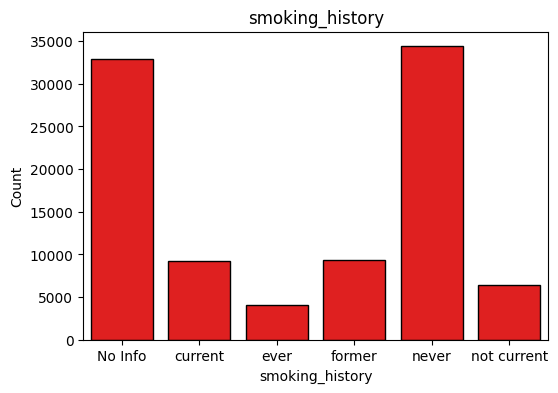

In [48]:
categorical_cols=df.select_dtypes(include=['object','category']).columns
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, color='red', edgecolor='black')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

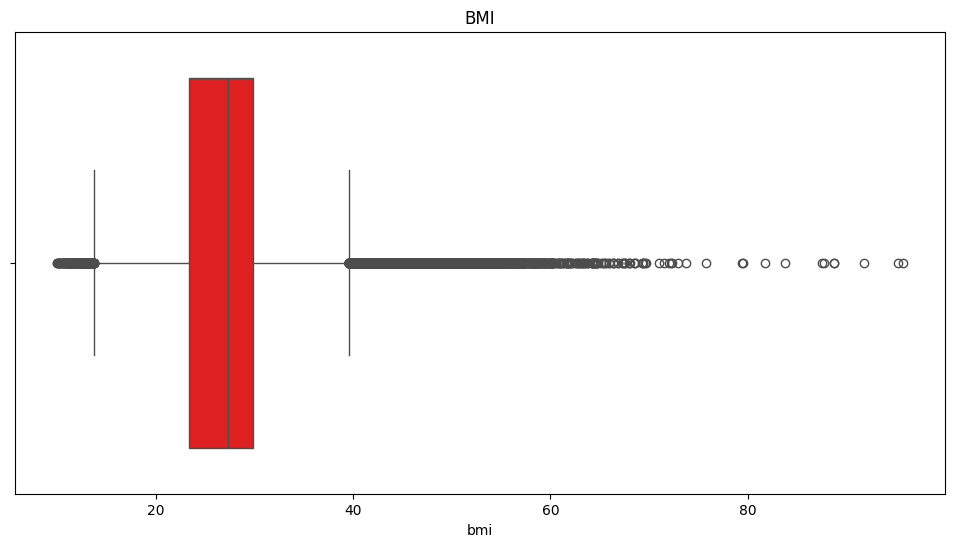

In [49]:
plt.figure(figsize=(12,6)) 
sns.boxplot(x=df['bmi'], color='red',)
plt.title('BMI')
plt.show()

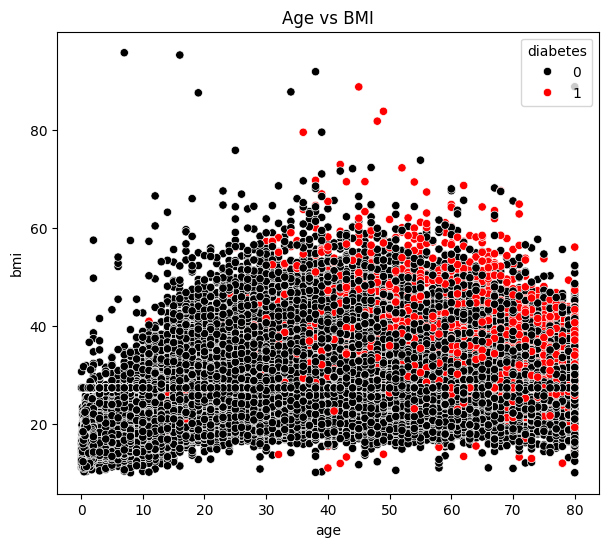

In [50]:
plt.figure(figsize=(7,6))
sns.scatterplot(data= df, x='age', y='bmi', hue='diabetes', palette=['black','red'])
plt.title('Age vs BMI')
plt.show()

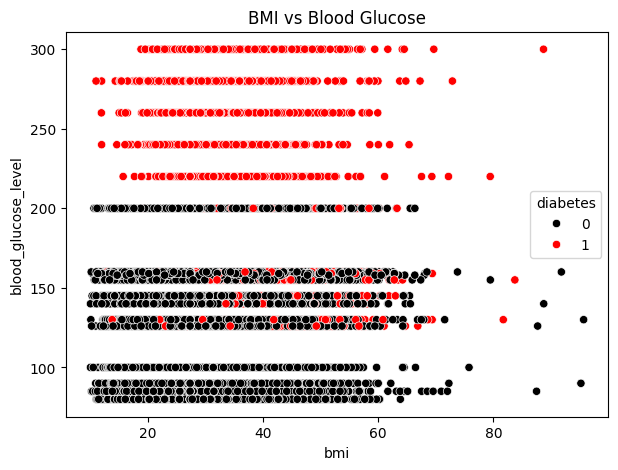

In [51]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='bmi', y='blood_glucose_level', hue='diabetes', data=df, palette=['black','red'])
plt.title('BMI vs Blood Glucose')
plt.show()

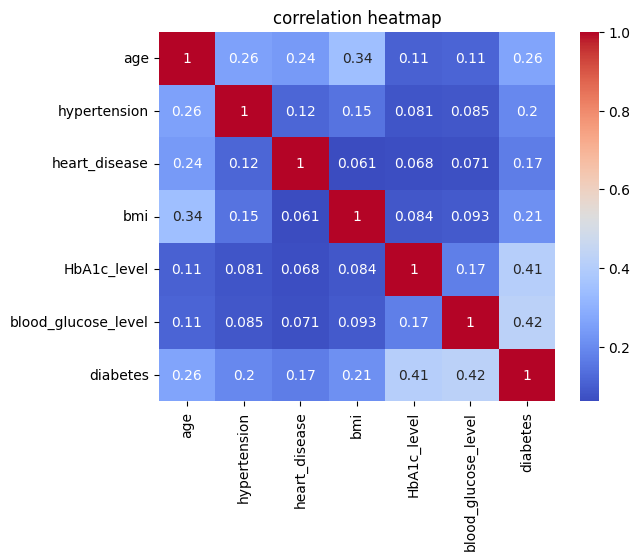

In [52]:
numeric_df =df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

Feature Engineering

In [53]:
df_encoded = df.copy()
label_cols = ['gender','smoking_history']
le=LabelEncoder() 
for col in label_cols:
    df_encoded[col]=le.fit_transform(df_encoded[col])

In [54]:
X = df_encoded.drop('diabetes', axis=1)
Y = df_encoded['diabetes']

rf=RandomForestClassifier(random_state=42)
rf.fit(X,Y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

selected_features = importances.head(5).index.tolist()
print("Selected Features:", selected_features)

X_selected = X[selected_features]

HbA1c_level            0.393414
blood_glucose_level    0.321550
bmi                    0.123642
age                    0.102842
smoking_history        0.027707
hypertension           0.015430
heart_disease          0.009188
gender                 0.006227
dtype: float64
Selected Features: ['HbA1c_level', 'blood_glucose_level', 'bmi', 'age', 'smoking_history']


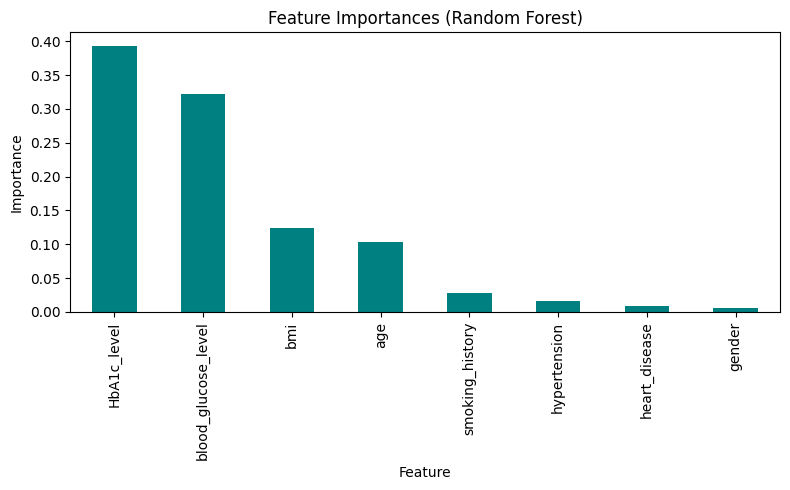

In [55]:
plt.figure(figsize=(8,5))
importances.plot(kind='bar', color='teal')
plt.title("Feature Importances (Random Forest)")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

Train Test Split

In [56]:
X_final = X_selected
Y_final = Y

X_train, X_temp, Y_train, Y_temp = train_test_split(X_final, Y_final, test_size=0.3, random_state=42, stratify=Y_final)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp)

print('Train shape:', X_train.shape, Y_train.shape) #to check the shape of dataset which is used
print('Validation shape:', X_val.shape,)
print('Test shape:', X_test.shape,)

Train shape: (67302, 5) (67302,)
Validation shape: (14422, 5)
Test shape: (14422, 5)


In [57]:
print("Original:", Counter(Y_train))

target_minority = 10000

n_min = sum(Y_train == 1)
n_maj = sum(Y_train == 0)

max_minority = min(target_minority, n_maj)

sampling_ratio = max_minority / n_maj

sm = SMOTE(sampling_strategy=sampling_ratio, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, Y_train)

print("Counts after SMOTE:", Counter(y_train_res))
print("Train after SMOTE:", X_train_res.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Original: Counter({0: 61365, 1: 5937})
Counts after SMOTE: Counter({0: 61365, 1: 10000})
Train after SMOTE: (71365, 5)
Val: (14422, 5)
Test: (14422, 5)


In [58]:
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Model Selection

In [59]:
#Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_res, y_train_res)

y_val_pred_log = log_model.predict(X_val)

val_acc_log = accuracy_score(Y_val, y_val_pred_log)
print("Validation Accuracy:", val_acc_log)
print(classification_report(Y_val, y_val_pred_log))

Validation Accuracy: 0.9505616419359312
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     13149
           1       0.76      0.65      0.70      1273

    accuracy                           0.95     14422
   macro avg       0.86      0.81      0.84     14422
weighted avg       0.95      0.95      0.95     14422



In [60]:
#DecisionTree

dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_res,y_train_res)

y_val_predt_dt = dt_model.predict(X_val)
print("validation accuracy:", accuracy_score(Y_val, y_val_predt_dt))
print(classification_report(Y_val, y_val_predt_dt))

validation accuracy: 0.9464013312994037
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     13149
           1       0.68      0.74      0.71      1273

    accuracy                           0.95     14422
   macro avg       0.83      0.85      0.84     14422
weighted avg       0.95      0.95      0.95     14422



In [61]:
#Random Forest

rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res,y_train_res)

y_val_predt_rf = rf_model.predict(X_val)
print("validation accuracy:", accuracy_score(Y_val, y_val_predt_rf))
print(classification_report(Y_val, y_val_predt_rf))



validation accuracy: 0.9654000832062127
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13149
           1       0.90      0.68      0.78      1273

    accuracy                           0.97     14422
   macro avg       0.94      0.84      0.88     14422
weighted avg       0.96      0.97      0.96     14422



In [62]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf_balanced.fit(X_train_res, y_train_res)

y_val_pred_bal = rf_balanced.predict(X_val)

val_acc_bal = accuracy_score(Y_val, y_val_pred_bal)
print("Random Forest (class_weight='balanced') - Validation Accuracy:", val_acc_bal)
print(classification_report(Y_val, y_val_pred_bal))

Random Forest (class_weight='balanced') - Validation Accuracy: 0.9647066981001248
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13149
           1       0.90      0.67      0.77      1273

    accuracy                           0.96     14422
   macro avg       0.94      0.83      0.88     14422
weighted avg       0.96      0.96      0.96     14422



In [64]:
y_val_probs = rf_balanced.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)

best_f1 = 0
best_threshold = 0
f1_scores = []

for thr in thresholds:
    y_val_pred_thr = (y_val_probs >= thr).astype(int)
    f1 = f1_score(Y_val, y_val_pred_thr, pos_label=1)
    f1_scores.append(f1)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr

print(f"Best threshold for class 1: {best_threshold}")
print(f"Best F1-score for class 1: {best_f1}")

Best threshold for class 1: 0.8899999999999996
Best F1-score for class 1: 0.7876190476190477


In [65]:
threshold = 0.89
y_val_pred = (y_val_probs >= threshold).astype(int)

val_acc = accuracy_score(Y_val, y_val_pred)
print("Random Forest - Validation Accuracy :", val_acc)
print(classification_report(Y_val, y_val_pred))

Random Forest - Validation Accuracy : 0.9690750242684787
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     13149
           1       1.00      0.65      0.79      1273

    accuracy                           0.97     14422
   macro avg       0.98      0.82      0.89     14422
weighted avg       0.97      0.97      0.97     14422



Model Training

In [67]:
X_train_final = np.concatenate([X_train, X_val], axis=0)
y_train_final = np.concatenate([Y_train, Y_val], axis=0)

In [68]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
)
rf_final.fit(X_train_final, y_train_final)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [69]:
y_test_probs = rf_final.predict_proba(X_test.values)[:, 1]
threshold = 0.89
y_test_pred = (y_test_probs >= threshold).astype(int)

In [71]:
test_acc = accuracy_score(Y_test, y_test_pred)
print("Random Forest - Test Accuracy:", test_acc)
print(classification_report(Y_test, y_test_pred))

Random Forest - Test Accuracy: 0.9730273193731799
              precision    recall  f1-score   support

           0       0.97      1.00      0.99     13150
           1       1.00      0.69      0.82      1272

    accuracy                           0.97     14422
   macro avg       0.99      0.85      0.90     14422
weighted avg       0.97      0.97      0.97     14422



Model Evaluation

In [73]:
accuracy  = accuracy_score(Y_test, y_test_pred)
precision = precision_score(Y_test, y_test_pred, zero_division=0)
recall    = recall_score(Y_test, y_test_pred, zero_division=0)
f1        = f1_score(Y_test, y_test_pred, zero_division=0)
roc_auc   = roc_auc_score(Y_test, y_test_probs)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")
print("Classification Report:\n")
print(classification_report(Y_test, y_test_pred))

Accuracy : 0.9730
Precision: 1.0000
Recall   : 0.6942
F1-score : 0.8195
ROC-AUC  : 0.9641

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     13150
           1       1.00      0.69      0.82      1272

    accuracy                           0.97     14422
   macro avg       0.99      0.85      0.90     14422
weighted avg       0.97      0.97      0.97     14422



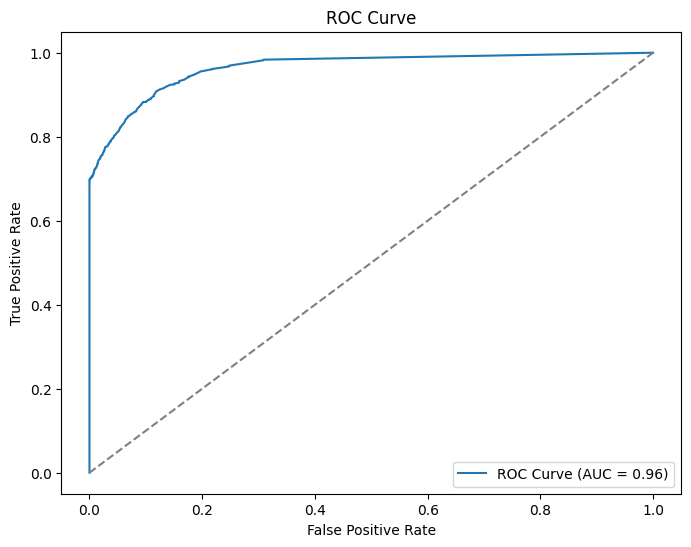

In [75]:
fpr, tpr, thresholds = roc_curve(Y_test, y_test_probs)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Hyperparameter tuning

In [ ]:
# Enhanced ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(Y_test, y_test_probs)
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8')

# Main ROC curve with enhanced styling
plt.plot(fpr, tpr, color='#2E86AB', linewidth=3, label=f'ROC Curve (AUC = {roc_auc:.3f})', alpha=0.8)

# Diagonal reference line
plt.plot([0,1], [0,1], linestyle='--', color='#A23B72', linewidth=2, alpha=0.7, label='Random Classifier')

# Fill area under curve
plt.fill_between(fpr, tpr, alpha=0.2, color='#2E86AB')

# Customize axes
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve - Diabetes Risk Prediction', fontsize=16, fontweight='bold', pad=20)

# Add grid
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Customize legend
plt.legend(loc='lower right', fontsize=11, framealpha=0.9, shadow=True)

# Set axis limits and ticks
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xticks(np.arange(0, 1.1, 0.1), fontsize=10)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=10)

# Add text annotation for AUC score
plt.text(0.6, 0.2, f'AUC = {roc_auc:.3f}', fontsize=14, fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [10, 15, 20],          
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6],    
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

grid = GridSearchCV(
    rf,
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)


grid.fit(X_train, Y_train)

print("Best params:", grid.best_params_)
print("Best F1 Score (CV):", grid.best_score_)


best_rf = grid.best_estimator_
best_rf.fit(X_train, Y_train)


y_train_pred = best_rf.predict(X_train)
y_test_pred  = best_rf.predict(X_test)
